# Experiment 01 (Advanced): NLP Pipeline, Linguistic Analysis, and Named Entity Recognition
## Title: Advanced Tokenization, POS Tagging, Lemmatization, Dependency Parsing, and NER on Anime Dialogues

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 01: Import Libraries and Download NLP Resources 

In [1]:
import nltk 
import spacy
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLTK Resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer, SnowballStemmer

# Load SpaCy English model
try: 
    nlp = spacy.load("en_core_web_sm")
except OSError:
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Advanced NLP Libraries Loaded & Resources Initialized Successfully!")

Advanced NLP Libraries Loaded & Resources Initialized Successfully!


### Step 02: Load Anime Speech Dataset

In [2]:
anime_text = """People's dreams have no end! If you don't take risks, you can't create a future.
I will take a potato chip and eat it! I watched Light Yagami write his name on the Death Note paper.
Wake up to reality! Nothing ever goes as planned in this accursed world.
I saw the Shinigami Ryuk with the notebook standing near the old library in Tokyo. If you win, you live. If you lose, you die.
The Hokage Naruto Uzumaki is the one who walks in front of everyone and endures all the pain in Konoha village."""

print("Anime Speech Corpus: \n")
print("="*130)
print(anime_text)
print("="*130)

Anime Speech Corpus: 

People's dreams have no end! If you don't take risks, you can't create a future.
I will take a potato chip and eat it! I watched Light Yagami write his name on the Death Note paper.
Wake up to reality! Nothing ever goes as planned in this accursed world.
I saw the Shinigami Ryuk with the notebook standing near the old library in Tokyo. If you win, you live. If you lose, you die.
The Hokage Naruto Uzumaki is the one who walks in front of everyone and endures all the pain in Konoha village.


### Step 03: Sentence & Word Tokenization (NLTK Vs SpaCy Comparision)

In [3]:
# NLTK Tokenization
nltk_sentences = sent_tokenize(anime_text)
nltk_words     = word_tokenize(anime_text)

# SpaCy Tokeniztion 
doc = nlp(anime_text)
spacy_sentences = [sent.text.strip() for sent in doc.sents]
spacy_words     = [token.text for token in doc]

print(f"Number of Sentences -> NLTK: {len(nltk_sentences)}  | SpaCy: {len(spacy_sentences)}")
print(f"Number of Words     -> NLTK: {len(nltk_words)} | SpaCy: {len(spacy_words)}")

print("\nNLTK Sentences:")
for i, sent in enumerate(nltk_sentences, 1):
    print(f"[{i}]  {sent}")

# print("\nSpaCy Sentences:")
# for i, sent in enumerate(spacy_sentences, 1):
#     print(f"[{i}]  {sent}")

Number of Sentences -> NLTK: 10  | SpaCy: 10
Number of Words     -> NLTK: 111 | SpaCy: 115

NLTK Sentences:
[1]  People's dreams have no end!
[2]  If you don't take risks, you can't create a future.
[3]  I will take a potato chip and eat it!
[4]  I watched Light Yagami write his name on the Death Note paper.
[5]  Wake up to reality!
[6]  Nothing ever goes as planned in this accursed world.
[7]  I saw the Shinigami Ryuk with the notebook standing near the old library in Tokyo.
[8]  If you win, you live.
[9]  If you lose, you die.
[10]  The Hokage Naruto Uzumaki is the one who walks in front of everyone and endures all the pain in Konoha village.


### Step 04: Advanced Stopword & Noise Removal 

In [4]:
stop_words = set(stopwords.words('english'))

# Filter non-alpha tokens and stopwords

filtered_tokens = [w for w in nltk_words if w.isalpha() and w.lower() not in stop_words]

print("Tokens Before Filtering (Alpha Only)        : ", len([w for w in nltk_words if w.isalpha()]))
print("Tokens After Filtering  (Alpha + Stopwords) : ", len(filtered_tokens))
print("\nSample Filtered Tokens: ")
print(filtered_tokens[:20])

Tokens Before Filtering (Alpha Only)        :  95
Tokens After Filtering  (Alpha + Stopwords) :  52

Sample Filtered Tokens: 
['People', 'dreams', 'end', 'take', 'risks', 'ca', 'create', 'future', 'take', 'potato', 'chip', 'eat', 'watched', 'Light', 'Yagami', 'write', 'name', 'Death', 'Note', 'paper']


### Step 05: Comparative Stemming Vs Context-Aware Lemmatization

In [5]:
porter = PorterStemmer()
snowball = SnowballStemmer("english")
wordnet_lemmatizer = WordNetLemmatizer()

comparison_data = []
unique_words = sorted(list(set(filtered_tokens)))

for word in unique_words:
    p_stem = porter.stem(word)
    s_stem = snowball.stem(word)
    wn_lemma = wordnet_lemmatizer.lemmatize(word.lower(), pos='v') # Lemmatize as verb

    spacy_tok = nlp(word)[0]
    sp_lemma = spacy_tok.lemma_

    comparison_data.append({
        "Original Word" : word,
        "Porter Stem"   : p_stem,
        "Snowball Stem" : s_stem,
        "WordNet Lemma" : wn_lemma,
        "SpaCy Lemma"   : sp_lemma
    })

df_compare = pd.DataFrame(comparison_data)
print(f"Comparison Table (Total Unique Words : {len(df_compare)}) : ")
df_compare.head(15)


Comparison Table (Total Unique Words : 51) : 


,Original Word,Porter Stem,Snowball Stem,WordNet Lemma,SpaCy Lemma
0,Death,death,death,death,death
1,Hokage,hokag,hokag,hokage,hokage
2,Konoha,konoha,konoha,konoha,Konoha
3,Light,light,light,light,light
4,Naruto,naruto,naruto,naruto,naruto
5,Note,note,note,note,note
6,Nothing,noth,noth,nothing,nothing
7,People,peopl,peopl,people,People
8,Ryuk,ryuk,ryuk,ryuk,Ryuk
9,Shinigami,shinigami,shinigami,shinigami,Shinigami


### Step 06: Detailed Part-Of-Speech (POS) Tagging and Morphological Analysis

In [6]:
pos_data = []
for token in doc:
    if not token.is_punct and not token.is_space:
        pos_data.append({
            "Token"             : token.text,
            "Lemma"             : token.lemma_,
            "Coarse POS (UPOS)" : token.pos_,
            "Fine POS (XPOS)"   : token.tag_,
            "POS Meaning"       : spacy.explain(token.tag_),
        })

df_pos = pd.DataFrame(pos_data)
print("Sample POS Analysis DataFrame: ")
df_pos.head(15)

Sample POS Analysis DataFrame: 


,Token,Lemma,Coarse POS (UPOS),Fine POS (XPOS),POS Meaning
0,People,People,NOUN,NNS,"noun, plural"
1,'s,'s,PART,POS,possessive ending
2,dreams,dream,NOUN,NNS,"noun, plural"
3,have,have,VERB,VBP,"verb, non-3rd person singular present"
4,no,no,DET,DT,determiner
5,end,end,NOUN,NN,"noun, singular or mass"
6,If,if,SCONJ,IN,"conjunction, subordinating or preposition"
7,you,you,PRON,PRP,"pronoun, personal"
8,do,do,AUX,VBP,"verb, non-3rd person singular present"
9,n't,not,PART,RB,adverb


### Step 07: Named Entity Recognition (NER)

In [7]:
ner_data = []
for ent in doc.ents:
    ner_data.append({
        "Entity" : ent.text,
        "Label"  : ent.label_,
        "Meaning": spacy.explain(ent.label_)
    })
df_ner = pd.DataFrame(ner_data).drop_duplicates().reset_index(drop=True)
print("Extracted Named Entities (NER) DataFrame: ")
df_ner

Extracted Named Entities (NER) DataFrame: 


,Entity,Label,Meaning
0,Yagami,PERSON,"People, including fictional"
1,Tokyo,GPE,"Countries, cities, states"
2,The Hokage Naruto Uzumaki,ORG,"Companies, agencies, institutions, etc."
3,Konoha,GPE,"Countries, cities, states"


### Step 08: Dependency Parsing and Subject-Verb-Object (SVO) Extraction

In [8]:
# Analyse sentence 4
sample_sent_doc = nlp(nltk_sentences[3])

print(f"Sentence: \"{sample_sent_doc.text}\"\n")
print(f"{'Token':15s} | {'Dependency (dep)':18s} | {'Head Text':15s} | {'Head POS' :10s}  |")
print("-"*70)
for token in sample_sent_doc:
    print(f"{token.text:15s} | {token.dep_:18s} | {token.head.text:15s} | {token.head.pos_:10s}  |")

Sentence: "I watched Light Yagami write his name on the Death Note paper."

Token           | Dependency (dep)   | Head Text       | Head POS    |
----------------------------------------------------------------------
I               | nsubj              | watched         | VERB        |
watched         | ROOT               | watched         | VERB        |
Light           | compound           | Yagami          | PROPN       |
Yagami          | nsubj              | write           | VERB        |
write           | ccomp              | watched         | VERB        |
his             | poss               | name            | NOUN        |
name            | dobj               | write           | VERB        |
on              | prep               | write           | VERB        |
the             | det                | paper           | NOUN        |
Death           | compound           | Note            | NOUN        |
Note            | compound           | paper           | NOUN        |
p

### Step 09: Lingusitic & Structural Ambiguity Analysis

In [9]:
print("1. Lexical Ambiguity Example")
print("Sentence A: 'I watched Light Yagami write his name on the Death Note paper.'")
print("Sentence B: 'Turn on the Light, it is dark in this Shinigami realm.'")
print("-> 'Light' refers to proper name (Light Yagami) in Sentence A vs noun (illumination) in Sentence B.\n")

print("2. Syntactic / Prepositional Attachment Ambiguity Example")
print("Sentence: 'I saw the Shinigami Ryuk with the notebook standing near the old library.'")
print("-> Syntactic ambiguity: 'with the notebook' can attach to 'saw' (I used a notebook to see) or 'Shinigami Ryuk' (Ryuk was holding the notebook).")

1. Lexical Ambiguity Example
Sentence A: 'I watched Light Yagami write his name on the Death Note paper.'
Sentence B: 'Turn on the Light, it is dark in this Shinigami realm.'
-> 'Light' refers to proper name (Light Yagami) in Sentence A vs noun (illumination) in Sentence B.

2. Syntactic / Prepositional Attachment Ambiguity Example
Sentence: 'I saw the Shinigami Ryuk with the notebook standing near the old library.'
-> Syntactic ambiguity: 'with the notebook' can attach to 'saw' (I used a notebook to see) or 'Shinigami Ryuk' (Ryuk was holding the notebook).


### Step 10: Comparative Visualizations & Analytics 

C:\Users\hp\AppData\Local\Temp\ipykernel_30180\425282350.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pos_counts.index, y=pos_counts.values, ax=axes[0], palette="viridis")


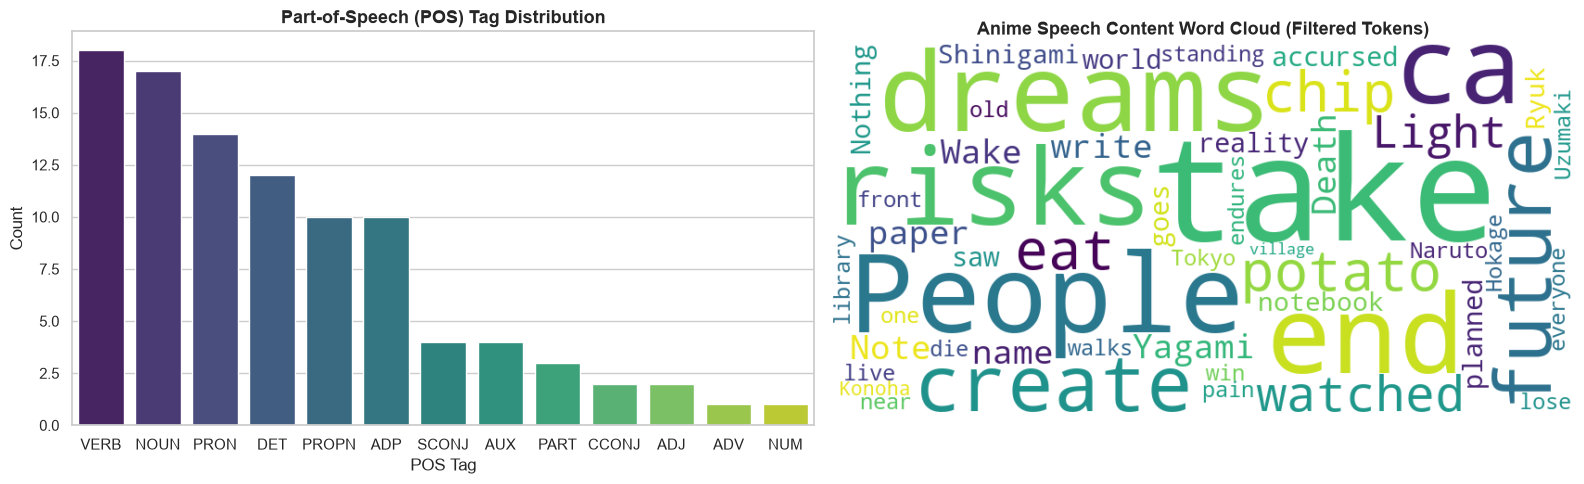

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. POS Tag Frequency Bar Plot
pos_counts = df_pos["Coarse POS (UPOS)"].value_counts()
sns.barplot(x=pos_counts.index, y=pos_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Part-of-Speech (POS) Tag Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("POS Tag")
axes[0].set_ylabel("Count")

# 2. WordCloud Visualization of Lemmas
test_for_wordcloud = " ".join(filtered_tokens)
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(test_for_wordcloud)

axes[1].imshow(wordcloud, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Anime Speech Content Word Cloud (Filtered Tokens)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Step 11: Modualar Reusable AnimeNLPPipeline Class for NLP Tasks

In [11]:
class AnimeNLPPipeline:
    def __init__(self, spacy_model="en_core_web_sm"):
        self.nlp        = spacy.load(spacy_model)
        self.stop_words = set(stopwords.words("english"))

    def process_speech(self, speech_text):
        doc = self.nlp(speech_text)

        tokens   = [t.text for t in doc if t.is_alpha]
        filtered = [t for t in tokens if t.lower() not in self.stop_words]
        lemmas   = [t.lemma_ for t in doc if t.is_alpha and t.text.lower() not in self.stop_words]
        entities = [(ent.text, ent.label_) for ent in doc.ents]

        return {
            "num_sentences"       : len(list(doc.sents)),
            "num_tokens"          : len(tokens),
            "num_filtered_words"  : len(filtered),
            "unique_lemmas"       : list(set(lemmas)),
            "entities"            : entities
        } 

# Test Pipeline With a New Anime Speech
sample_quote = "I am going to become the King of the Pirates! - Monkey D. Luffy"
pipeline = AnimeNLPPipeline()
result = pipeline.process_speech(sample_quote)

print("AnimeNLPPipeline Processing Result:")
print(f"Quote: \"{sample_quote}\"")
for key, value in result.items():
    print(f"{key.replace('_', ' ').title():30s} : {value}")


AnimeNLPPipeline Processing Result:
Quote: "I am going to become the King of the Pirates! - Monkey D. Luffy"
Num Sentences                  : 2
Num Tokens                     : 12
Num Filtered Words             : 6
Unique Lemmas                  : ['become', 'Monkey', 'King', 'Luffy', 'Pirates', 'go']
Entities                       : [('the King of the Pirates', 'PERSON')]


### Step 12: Final Output & Summary Report 

In [12]:
print("="*63)
print("     Advanced NLP Practical 01 Completed Successfully!    ")
print("="*63)
print(f"Sentences Analyzed        : {len(spacy_sentences)}")
print(f"Total Words Processed     : {len(spacy_words)}")
print(f"Filtered Content Tokens   : {len(filtered_tokens)}")
print(f"Unique Lemmatized Terms   : {len(df_compare)}")
print(f"Named Entities Identified : {len(df_ner)}")
print("POS & Syntactic Parsing   : Complete (UPOS, XPOS, Dependency)")
print("Modular Pipeline Class    : Successfully Constructed & Tested")
print("="*63)

     Advanced NLP Practical 01 Completed Successfully!    
Sentences Analyzed        : 10
Total Words Processed     : 115
Filtered Content Tokens   : 52
Unique Lemmatized Terms   : 51
Named Entities Identified : 4
POS & Syntactic Parsing   : Complete (UPOS, XPOS, Dependency)
Modular Pipeline Class    : Successfully Constructed & Tested
